In [3]:
from neural_priors.utils.data import get_all_behavioral_data, get_all_subject_ids
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, pickle
from scipy import stats, odr, optimize
import statsmodels.api as sm
import itertools

In [4]:
from functools import cache

In [5]:
# def obvious_index_filter(df, **kwargs):
#     r = df
#     for k,v in kwargs.items():
#         r = r.xs(v, level=k)
#     return r

def index_filter(df, **kwargs):
    """
    Filter a DataFrame based on index level value(s) and drop levels uniquely determined
    by a single-value filter. Can also filter by column values.

    For a MultiIndex, only those levels filtered by a single element (not list-like)
    that then have only one unique value in the result are dropped.
    For a simple index, if the filtering criterion is a single element and the index
    becomes constant, the index is reset (dropped).

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        **kwargs: Each keyword corresponds to an index level name (or column name) and its filter condition.
                  The condition may be a single value or a list/tuple/set of acceptable values.
                  If the key is not an index level, it will be treated as a column name.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # No filters provided; return the original DataFrame.
    if not kwargs:
        return df

    idx = df.index
    result_df = df

    # Separate index-level filters from column filters
    index_filters = {}
    column_filters = {}
    
    if isinstance(idx, pd.MultiIndex):
        for level, value in kwargs.items():
            if level in idx.names:
                index_filters[level] = value
            elif level in df.columns:
                column_filters[level] = value
            else:
                raise KeyError(f"'{level}' not found in MultiIndex levels {idx.names} or columns.")
    else:
        for level, value in kwargs.items():
            if idx.name == level:
                index_filters[level] = value
            elif level in df.columns:
                column_filters[level] = value
            else:
                raise KeyError(f"'{level}' not found in index or columns.")

    # MultiIndex handling.
    if isinstance(idx, pd.MultiIndex) and index_filters:
        mask = np.ones(len(result_df), dtype=bool)
        # Build the mask for each provided index level.
        for level, value in index_filters.items():
            if not isinstance(value, str) and hasattr(value, '__iter__'): #isinstance(value, (list, tuple, set)):
                mask &= idx.get_level_values(level).isin(value)
            else:
                mask &= (idx.get_level_values(level) == value)
        result_df = result_df[mask]

        # Only drop levels that were filtered with a single value and are constant.
        to_drop = [level for level, value in index_filters.items() 
                   if not isinstance(value, (list, tuple, set)) 
                   and result_df.index.get_level_values(level).nunique() == 1]
        if to_drop:
            # If we're dropping all levels, reset the index instead
            if len(to_drop) == len(result_df.index.names):
                result_df = result_df.reset_index(drop=True)
            else:
                result_df = result_df.droplevel(to_drop)

    # Simple index handling.
    elif index_filters:
        if len(index_filters) > 1:
            raise ValueError("A simple index DataFrame accepts only one filtering criterion.")
        key, value = next(iter(index_filters.items()))
        # Apply the filtering.
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            mask = idx.isin(value)
        else:
            mask = (idx == value)
        result_df = result_df[mask]

        # Drop the index (by resetting it) only if the filter was a single value and the index is constant.
        if not isinstance(value, (list, tuple, set)) and result_df.index.nunique() == 1:
            result_df = result_df.reset_index(drop=True)

    # Column filtering
    for col, value in column_filters.items():
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            result_df = result_df[result_df[col].isin(value)]
        else:
            result_df = result_df[result_df[col] == value]

    return result_df


## likelihoods

In [6]:
all_likelihoods = pd.read_csv('all_likelihoods.tsv', sep='\t', ) #index_col=[0, 1, 2, 3, 4], ) #header=[0, 1, ])
assert len( all_likelihoods[~all_likelihoods.smoothed] ) == 0
all_likelihoods = all_likelihoods.drop(columns=['smoothed'])
all_likelihoods = all_likelihoods.set_index(['model', 'fit_responses', 'subject',])


In [7]:
all_likelihoods

voxel  loglikelihood
model fit_responses subject                      
15    False         13           0    -425.876882
                    13           1    -517.608699
                    13           2    -442.974705
                    13           3    -793.270234
                    13           4    -715.382202
...                            ...            ...
4     True          35        1095    -300.331638
                    35        1096    -199.522127
                    35        1097    -353.415688
                    35        1098    -343.514957
                    35        1099    -514.307309

[427462 rows x 2 columns]

In [32]:
sorted( all_likelihoods.index.get_level_values('model').unique() )

[-1, 0, 3, 4, 5, 15, 31]

In [9]:
all_likelihoods.index.get_level_values('subject').unique()

Index([13, 14, 22, 25, 40, 24, 15, 12, 41, 30,  8, 37,  1, 39,  6, 38,  7,  9,
       36, 31, 17, 28, 10, 26, 19, 21, 20, 27, 18, 16, 29, 34, 33,  5,  2,  3,
        4, 32, 35],
      dtype='int64', name='subject')

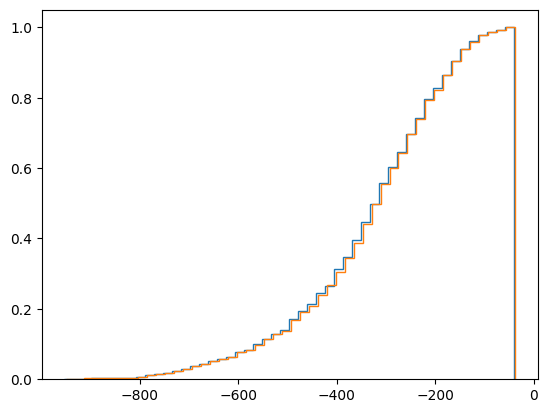

In [10]:
plt.hist( index_filter(all_likelihoods, fit_responses=True, model=-1, subject=10).loglikelihood, bins=50, cumulative=True, density=True, histtype='step');
plt.hist( index_filter(all_likelihoods, fit_responses=True, model=31, subject=10).loglikelihood, bins=50, cumulative=True, density=True, histtype='step');

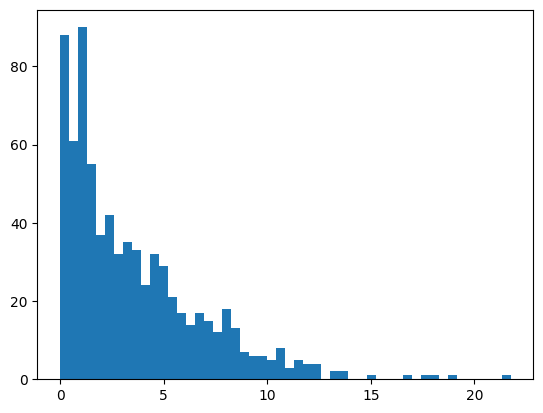

In [11]:
plt.hist( index_filter(all_likelihoods, fit_responses=True, model=31, subject=10).loglikelihood 
        - index_filter(all_likelihoods, fit_responses=True, model=-1, subject=10).loglikelihood, bins=50 );

In [12]:
index_filter(all_likelihoods, fit_responses=True, subject=41)

,voxel,loglikelihood
model,,
-1,0,-732.707699
-1,1,-423.664093
-1,2,-411.818425
-1,3,-323.770845
-1,4,-299.737380
...,...,...
4,689,-283.338939
4,690,-157.287073
4,691,-294.927510


## cvr2s

In [13]:
#bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth, pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

print( pars.index.unique(level='smoothed') )
pars = pars.droplevel('smoothed')

pars.index.set_names('voxel', level=-1, inplace=True)

pars

Index([True], dtype='bool', name='smoothed')


parameter                                      mu                   sd  \
range                                      narrow       wide    narrow   
type         subject model_label voxel                                   
ground_truth 1       0           0      10.698851  10.698851  0.128387   
                                 1      12.097051  12.097051  0.047358   
                                 2      13.019329  13.019329  0.156827   
                                 3      15.027272  15.027272  0.071559   
                                 4      11.410503  11.410503  0.092538   
...                                           ...        ...       ...   
estimates    41      33          689    13.448326  16.896652  0.565678   
                                 690     9.908031   9.908031  0.152317   
                                 691    13.634396  17.268791  0.521635   
                                 692     8.510156   8.510156  0.498837   
                                 693    13.615266  17.230532  0.599750   

parameter                                        delta_wide      amplitude  \
range                                       wide     narrow wide    narrow   
type         subject model_label voxel                                       
ground_truth 1       0           0      0.128387        1.0  1.0  0.287954   
                                 1      0.047358        1.0  1.0  0.396764   
                                 2      0.156827        1.0  1.0  0.160411   
                                 3      0.071559        1.0  1.0  0.305217   
                                 4      0.092538        1.0  1.0  0.359884   
...                                          ...        ...  ...       ...   
estimates    41      33          689    0.728476        2.0  2.0  0.464496   
                                 690    0.196154        2.0  2.0  0.108694   
                                 691    0.671758        2.0  2.0  0.387509   
                                 692    0.642400        2.0  2.0  0.241137   
                                 693    0.772355        2.0  2.0  0.331217   

parameter                                         baseline            \
range                                       wide    narrow      wide   
type         subject model_label voxel                                 
ground_truth 1       0           0      0.287954 -0.117511 -0.117511   
                                 1      0.396764 -0.512096 -0.512096   
                                 2      0.160411 -0.514299 -0.514299   
                                 3      0.305217 -0.310229 -0.310229   
                                 4      0.359884 -0.109330 -0.109330   
...                                          ...       ...       ...   
estimates    41      33          689    0.518247 -0.045288 -0.045288   
                                 690    0.121272  0.277198  0.277198   
                                 691    0.432351 -0.075840 -0.075840   
                                 692    0.269041 -0.121465 -0.121465   
                                 693    0.369545 -0.205013 -0.205013   

parameter                                     r2      cvr2  
range                                        nan       nan  
type         subject model_label voxel                      
ground_truth 1       0           0      0.007678 -0.018960  
                                 1      0.007553 -0.019339  
                                 2      0.005133 -0.026036  
                                 3      0.014921 -0.021961  
                                 4      0.007671 -0.015200  
...                                          ...       ...  
estimates    41      33          689    0.029204  0.011950  
                                 690    0.006743 -0.015981  
                                 691    0.022160  0.002292  
                                 692    0.014179 -0.008607  
                                 693    0.007632 -0.006012  

[11602

In [14]:
pars.index.get_level_values('model_label').unique()

Index([0, 1, 2, 3, 4, 5, 12, 14, 15, 18, 25, 26, 27, 28, 29, 30, 31, 32, 33], dtype='int64', name='model_label')

In [15]:
index_filter(pars, model_label=26, type='estimates') #.cvr2 > 0

parameter             mu                   sd            delta_wide       \
range             narrow       wide    narrow       wide     narrow wide   
subject voxel                                                              
1       0       0.000000   0.000000  0.000000   0.000000        2.0  2.0   
        1       0.000000   0.000000  0.000000   0.000000        2.0  2.0   
        2       0.000000   0.000000  0.000000   0.000000        2.0  2.0   
        3       0.000000   0.000000  0.000000   0.000000        2.0  2.0   
        4       0.000000   0.000000  0.000000   0.000000        2.0  2.0   
...                  ...        ...       ...        ...        ...  ...   
41      689    13.507879  17.015759  7.673074  14.723872        2.0  2.0   
        690     9.920395   9.920395  1.202841   2.308132        2.0  2.0   
        691    15.599380  21.198760  1.183772   2.271541        2.0  2.0   
        692     9.621760   9.621760  6.464091  12.403954        2.0  2.0   
        693    15.610968  21.221935  1.039950   1.995562        2.0  2.0   

parameter     amplitude            baseline                  r2      cvr2  
range            narrow      wide    narrow      wide       nan       nan  
subject voxel                                                              
1       0      0.000000  0.000000  0.000000  0.000000  1.000000  0.493842  
        1      0.000000  0.000000  0.000000  0.000000  1.000000  0.470661  
        2      0.000000  0.000000  0.000000  0.000000  1.000000  0.486165  
        3      0.000000  0.000000  0.000000  0.000000  1.000000  0.489463  
        4      0.000000  0.000000  0.000000  0.000000  1.000000  0.494839  
...                 ...       ...       ...       ...       ...       ...  
41      689    0.467936  0.467936 -0.026718 -0.026718  0.027321 -0.000373  
        690    0.120050  0.120050  0.277141  0.277141  0.007352 -0.018303  
        691    0.300100  0.300100  0.191016  0.191016  0.028012 -0.000031  
        692    0.303619  0.303619 -0.218971 -0.218971  0.013356 -0.025054  
        693    0.253097  0.253097  0.046575  0.046575  0.012986 -0.005503  

[30533 rows x 12 columns]

In [16]:
# for each subject, find all the voxels for which at least one model yields cvr2>0
model_list = [0,1,2,3,4,5,14,15,31,32,33]
good_voxels = {}
for sid in pars.index.get_level_values('subject').unique():
    sdat_cvr2 = index_filter(pars, subject=sid, model_label=model_list).cvr2
    good_voxels[sid] = []
    voxels = sdat_cvr2.index.get_level_values('voxel').unique()
    for voxel in voxels:
        if ( index_filter( sdat_cvr2, voxel=voxel ) > 0 ).any().iloc[0]:
            good_voxels[sid].append(voxel)
    print(f'Subject {sid}: {len(good_voxels[sid])}/{len(voxels)} good voxels')
#good_voxels

Subject 1: 208/771 good voxels
Subject 2: 272/860 good voxels
Subject 3: 202/714 good voxels
Subject 4: 430/775 good voxels
Subject 5: 225/677 good voxels
Subject 6: 407/805 good voxels
Subject 7: 537/892 good voxels
Subject 8: 398/636 good voxels
Subject 9: 395/637 good voxels
Subject 10: 247/743 good voxels
Subject 12: 656/890 good voxels
Subject 13: 572/852 good voxels
Subject 14: 250/800 good voxels
Subject 15: 405/761 good voxels
Subject 16: 441/684 good voxels
Subject 17: 374/780 good voxels
Subject 18: 274/746 good voxels
Subject 19: 538/890 good voxels
Subject 20: 587/1009 good voxels
Subject 21: 170/798 good voxels
Subject 22: 596/1069 good voxels
Subject 24: 304/497 good voxels
Subject 25: 235/795 good voxels
Subject 26: 531/688 good voxels
Subject 27: 171/410 good voxels
Subject 28: 251/761 good voxels
Subject 29: 309/861 good voxels
Subject 30: 718/954 good voxels
Subject 31: 349/718 good voxels
Subject 32: 201/742 good voxels
Subject 33: 303/819 good voxels
Subject 34: 286

In [78]:
sum( len(vs) for vs in good_voxels.values() )

15109

## behavior

In [17]:
bids_folder = '../../ds-neuralpriors'

In [18]:
beh = get_all_behavioral_data(bids_folder=bids_folder)

In [19]:
# change first level index from string '01' to int 1
beh.index = beh.index.set_levels(beh.index.levels[0].astype(int), level=0)
beh

onset  phase  response  nr_frames     n  \
subject session run trial_nr                                                 
1       1       1   1          68.826307      5       NaN       30.0  11.0   
                    2          76.016292      5      19.0       31.0  23.0   
                    3          87.026471      5      25.0       30.0  23.0   
                    4          97.085656      5      24.0       30.0  22.0   
                    5         106.744768      5      17.0       31.0  21.0   
...                                  ...    ...       ...        ...   ...   
41      2       8   26        275.797056      5      25.0       30.0  24.0   
                    27        286.857371      5      24.0       30.0  19.0   
                    28        296.683059      5      22.0       30.0  17.0   
                    29        307.476458      5      19.0       30.0  19.0   
                    30        317.202043      5      19.0       30.0  19.0   

                              jitter  start_marker_position  response_time  \
subject session run trial_nr                                                 
1       1       1   1            6.0                   24.0            NaN   
                    2            4.0                   14.0       1.317963   
                    3            6.0                   11.0       0.834244   
                    4            5.0                   22.0       1.701381   
                    5            5.0                   22.0       2.018881   
...                              ...                    ...            ...   
41      2       8   26           4.0                   12.0       1.635028   
                    27           6.0                   15.0       1.701679   
                    28           5.0                   15.0       0.100000   
                    29           6.0                   20.0       1.751607   
                    30           5.0                   24.0       0.049945   

                               onset_abs  duration   range  error  abs_error  \
subject session run trial_nr                                                   
1       1       1   1          76.378611  0.500457  narrow    NaN        NaN   
                    2          83.568595  0.517188  narrow   -4.0        4.0   
                    3          94.578775  0.500469  narrow    2.0        2.0   
                    4         104.637959  0.500559  narrow    2.0        2.0   
                    5         114.297072  0.517009  narrow   -4.0        4.0   
...                                  ...       ...     ...    ...        ...   
41      2       8   26        278.746204  0.500532  narrow    1.0        1.0   
                    27        289.806518  0.500510  narrow    5.0        5.0   
                    28        299.632207  0.500525  narrow    5.0        5.0   
                    29        310.425606  0.500458  narrow    0.0        0.0   
                    30        320.151190  0.500598  narrow    0.0        0.0   

                              squared_error  
subject session run trial_nr                 
1       1       1   1                   NaN  
                    2                  16.0  
                    3                   4.0  
                    4                   4.0  
                    5                  16.0  
...                                     ...  
41      2       8   26                  1.0  
                    27                 25.0  
                    28                 25.0  
                    29                  0.0  
                    30                  0.0  

[18720 rows x 14 columns]

In [20]:
beh.groupby(['subject', 'range']).count()[['n', 'response']]

n  response
subject range                
1       narrow  240       236
        wide    240       231
2       narrow  240       238
        wide    240       238
3       narrow  240       233
...             ...       ...
39      wide    240       240
40      narrow  240       234
        wide    240       232
41      narrow  240       238
        wide    240       234

[78 rows x 2 columns]

In [21]:
beh.loc[1]

onset  phase  response  nr_frames     n  jitter  \
session run trial_nr                                                         
1       1   1          68.826307      5       NaN       30.0  11.0     6.0   
            2          76.016292      5      19.0       31.0  23.0     4.0   
            3          87.026471      5      25.0       30.0  23.0     6.0   
            4          97.085656      5      24.0       30.0  22.0     5.0   
            5         106.744768      5      17.0       31.0  21.0     5.0   
...                          ...    ...       ...        ...   ...     ...   
2       8   26        306.028786      5      15.0       30.0  12.0     6.0   
            27        316.621787      5      17.0       30.0  13.0     6.0   
            28        325.596882      5      20.0       30.0  18.0     4.0   
            29        334.855556      5      20.0       31.0  14.0     4.0   
            30        344.948077      5      19.0       28.0  17.0     6.0   

                      start_marker_position  response_time   onset_abs  \
session run trial_nr                                                     
1       1   1                          24.0            NaN   76.378611   
            2                          14.0       1.317963   83.568595   
            3                          11.0       0.834244   94.578775   
            4                          22.0       1.701381  104.637959   
            5                          22.0       2.018881  114.297072   
...                                     ...            ...         ...   
2       8   26                         18.0       0.166735  309.139009   
            27                         20.0       1.168014  319.732010   
            28                         10.0       1.351227  328.707105   
            29                         17.0       1.417941  337.965779   
            30                         21.0       0.016743  348.058300   

                      duration   range  error  abs_error  squared_error  
session run trial_nr                                                     
1       1   1         0.500457  narrow    NaN        NaN            NaN  
            2         0.517188  narrow   -4.0        4.0           16.0  
            3         0.500469  narrow    2.0        2.0            4.0  
            4         0.500559  narrow    2.0        2.0            4.0  
            5         0.517009  narrow   -4.0        4.0           16.0  
...                        ...     ...    ...        ...            ...  
2       8   26        0.500397  narrow    3.0        3.0            9.0  
            27        0.500710  narrow    4.0        4.0           16.0  
            28        0.500498  narrow    2.0        2.0            4.0  
            29        0.517191  narrow    6.0        6.0           36.0  
            30        0.500619  narrow    2.0        2.0            4.0  

[480 rows x 14 columns]

# BIC

In [22]:
@cache
def get_nobs(sid, condition, with_responses):
    dat = beh.loc[sid]
    dat = dat[dat['range'] == condition]
    return dat['response' if with_responses else 'n'].count()

In [23]:
get_nobs(1, 'narrow', with_responses=True)

236

- 0. No shift: $\mu_w=\mu_n$, $\sigma_w=\sigma_n$, and $a_w=a_n$.  
- 1. $\mu_w=2\mu_n$: $\mu_w=2\mu_n$, $\sigma_w=\sigma_n$, and $a_w=a_n$.
- 2. $\mu_w=r_\mu\mu_n$: $\mu_w=r_\mu\mu_n$, $\sigma_w=\sigma_n$, and $a_w=a_n$.
- 3. Free shifts: $\mu_w$ and $\mu_n$ free parameters, $\sigma_w=\sigma_n$, and $a_w=a_n$.
- 4. Efficient shifts: $\mu_w = 10 + 2(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w=\sigma_n$, and $a_w=a_n$.
- 5. Participant-specific slopes: $\mu_w = 10 + r_\mu(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w=\sigma_n$, and $a_w=a_n$.
- 14. Free widths: $\mu_w = 10 + 2(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w$ and $\sigma_n$ free parameters, and $a_w=a_n$.
- 31. Best-fitting: fixed width scaling: $\mu_w = 10 + 2(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w=1.3...\sigma_n$, and $a_w=a_n$.
- 15. Participant-specific scaling': $\mu_w = 10 + 2(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w=r_\sigma\sigma_n$, and $a_w=a_n$.
- 32. Free amplitudes': $\mu_w = 10 + 2(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w=1.3...\sigma_n$, and $a_w$ and $a_n$ free parameters.
- 33. Participant-specific amplitude ratio': $\mu_w = 10 + 2(\mu_n-10)$ if $\mu_n > 10$, else $\mu_w=\mu_n$; $\sigma_w=1.3...\sigma_n$, and $a_w= r_a a_n$.  



In [24]:
index_filter( all_likelihoods, model=31, fit_responses=True, subject=1).voxel.count()

771

In [25]:
all_likelihoods

voxel  loglikelihood
model fit_responses subject                      
15    False         13           0    -425.876882
                    13           1    -517.608699
                    13           2    -442.974705
                    13           3    -793.270234
                    13           4    -715.382202
...                            ...            ...
4     True          35        1095    -300.331638
                    35        1096    -199.522127
                    35        1097    -353.415688
                    35        1098    -343.514957
                    35        1099    -514.307309

[427462 rows x 2 columns]

In [26]:
@cache
def get_ll(sid, model, fit_responses):
    return index_filter(all_likelihoods, subject=sid, model=model, fit_responses=fit_responses, voxel=good_voxels[sid]).loglikelihood.sum()

In [27]:
get_ll(1, model=31, fit_responses=True)

-72737.05831400305

In [28]:
@cache
def get_penalty_baseline(sid, model, fit_responses):
    n_narrow = get_nobs(sid, 'narrow', with_responses=True)
    n_wide   = get_nobs(sid, 'wide', with_responses=True)
    num_voxels = len(good_voxels[sid]) #index_filter(all_likelihoods, subject=sid, model=model, fit_responses=fit_responses).voxel.count()
    # baseline parameter. Same in both conditions. One parameter for each voxel.
    return num_voxels * np.log(n_narrow + n_wide)

@cache
def get_penalty_amplitude(sid, model, fit_responses):
    n_narrow = get_nobs(sid, 'narrow', with_responses=True)
    n_wide   = get_nobs(sid, 'wide', with_responses=True)
    num_voxels = len(good_voxels[sid]) #index_filter(all_likelihoods, subject=sid, model=model, fit_responses=fit_responses).voxel.count()
    if model in [0, 1, 2, 3, 4, 5, 14, 15, 31]:
        # Same in both conditions. One parameter for each voxel, 
        penalty = num_voxels * np.log(n_narrow + n_wide)
    elif model in [32,]:
        # a_n and a_w free parameters, for each voxel.
        penalty = num_voxels * np.log(n_narrow) + num_voxels * np.log(n_wide)
    elif model in [33,]:
        # One parameter a_n for each voxel, + 1 ratio parameter
        penalty = (num_voxels+1) * np.log(n_narrow + n_wide)
    else:
        raise NotImplementedError
    return penalty

@cache
def get_penalty_width(sid, model, fit_responses):
    n_narrow = get_nobs(sid, 'narrow', with_responses=True)
    n_wide   = get_nobs(sid, 'wide', with_responses=True)
    num_voxels = len(good_voxels[sid]) #index_filter(all_likelihoods, subject=sid, model=model, fit_responses=fit_responses).voxel.count()
    if model in [0, 1, 2, 3, 4, 5,  31, 32, 33]:
        # One parameter for each voxel (Same in both conditions, for 0,1,2,3,4,5; scaled with fixed 1.3, for 31,32,33)
        penalty = num_voxels * np.log(n_narrow + n_wide)
    elif model in [14,]:
        # sigma_n and sigma_w free parameters, for each voxel.
        penalty = num_voxels * np.log(n_narrow) + num_voxels * np.log(n_wide)
    elif model in [15,]:
        # One parameter sigma_n for each voxel, + 1 ratio parameter
        penalty = (num_voxels+1) * np.log(n_narrow + n_wide)
    else:
        raise NotImplementedError
    return penalty

@cache
def get_penalty_mu(sid, model, fit_responses):
    n_narrow = get_nobs(sid, 'narrow', with_responses=True)
    n_wide   = get_nobs(sid, 'wide', with_responses=True)
    num_voxels = len(good_voxels[sid]) #index_filter(all_likelihoods, subject=sid, model=model, fit_responses=fit_responses).voxel.count()
    if model in [0, 1, 4, 14, 15, 31, 32, 33]:
        # One parameter mu_n for each voxel. 
        penalty = num_voxels * np.log(n_narrow + n_wide)
    elif model in [3,]:
        # mu_n and mu_w free parameters, for each voxel.
        penalty = num_voxels * np.log(n_narrow) + num_voxels * np.log(n_wide)
    elif model in [2, 5]:
        # One parameter mu_n for each voxel, + 1 ratio parameter
        penalty = (num_voxels + 1) * np.log(n_narrow + n_wide)
    else:
        raise NotImplementedError
    return penalty

In [29]:
def get_bic_subject(sid, model, fit_responses):
    ll = get_ll(sid, model, fit_responses)
    penalty = get_penalty_baseline(sid, model, fit_responses) \
                + get_penalty_amplitude(sid, model, fit_responses) \
                + get_penalty_width(sid, model, fit_responses) \
                + get_penalty_mu(sid, model, fit_responses)
    bic = -2 * ll + penalty
    return bic, ll, penalty

def get_bic(model, fit_responses):
    bics, lls, penalties = [], [], []
    for sid in all_likelihoods.index.get_level_values('subject').unique():
        bic, ll, penalty = get_bic_subject(sid, model, fit_responses)
        bics.append(bic)
        lls.append(ll)
        penalties.append(penalty)
    bic = np.sum(bics)
    ll = np.sum(lls)
    penalty = np.sum(penalties)
    return bic, ll, penalty



In [44]:
for model in [0, 3, 4, 5, 15, 31]:
    sid = 1
    bic, ll, penalty = get_bic_subject(sid, model, fit_responses=True)
    print(f'Model {model}, BIC: {bic-150306.48}, ll = {ll}, penalty = {penalty}')

Model 0, BIC: 229.54590658465168, ll = -72711.13998210208, penalty = 5113.745942380523
Model 3, BIC: 831.2157979369804, ll = -72516.94322095887, penalty = 6103.809356019252
Model 4, BIC: 56.93763003748609, ll = -72624.83584382849, penalty = 5113.745942380523
Model 5, BIC: 0.003271228924859315, ll = -72593.29549979538, penalty = 5119.892271638192
Model 15, BIC: 216.53111831267597, ll = -72701.55942333725, penalty = 5119.892271638192
Model 31, BIC: 281.3825703866023, ll = -72737.05831400305, penalty = 5113.745942380523


In [ ]:
bics = {}
for fit_responses in [True, False]:
     for model in [0, 3, 4, 5, 15, 31]:
        bic, ll, penalty = get_bic(model, fit_responses)
        print(f'Model {model}, fit resp {fit_responses}, BIC: {bic-11597700.74:.2f}, -ll = {-ll:.2f}, penalty = {penalty:.2f}')
        bics[(model, fit_responses)] = bic

Model 0,	fit resp True, BIC: 32461.88, -ll = 5629075.87, penalty = 372010.87
Model 3,	fit resp True, BIC: 48161.07, -ll = 5600897.19, penalty = 444067.43
Model 4,	fit resp True, BIC: 6338.26, -ll = 5616014.06, penalty = 372010.87
Model 5,	fit resp True, BIC: 0.00, -ll = 5612724.94, penalty = 372250.87
Model 15,	fit resp True, BIC: 5202.81, -ll = 5615326.34, penalty = 372250.87
Model 31,	fit resp True, BIC: 7177.60, -ll = 5616433.73, penalty = 372010.87
Model 0,	fit resp False, BIC: 43528.00, -ll = 5634608.93, penalty = 372010.87
Model 3,	fit resp False, BIC: 64786.30, -ll = 5609209.80, penalty = 444067.43
Model 4,	fit resp False, BIC: 28954.45, -ll = 5627322.16, penalty = 372010.87
Model 5,	fit resp False, BIC: 20873.37, -ll = 5623161.62, penalty = 372250.87
Model 15,	fit resp False, BIC: 26092.64, -ll = 5625771.25, penalty = 372250.87
Model 31,	fit resp False, BIC: 28546.96, -ll = 5627118.41, penalty = 372010.87


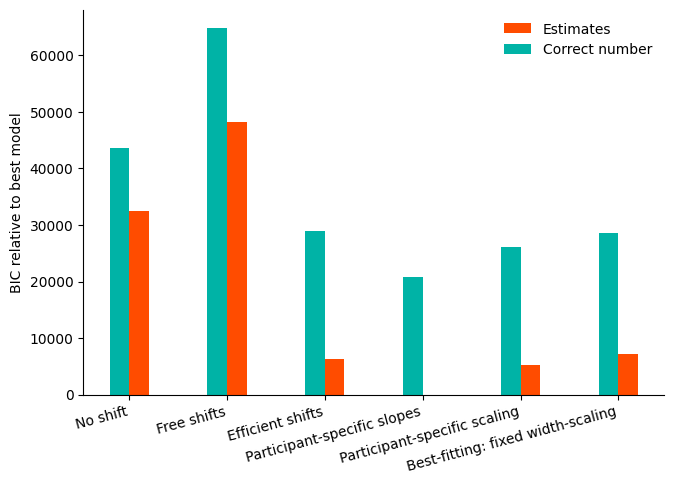

In [77]:
min_bic = min( bics.values() )
fig, ax = plt.subplots(figsize=(7.5, 5))
C_GT = plt.cm.winter(.7)
C_EST = plt.cm.autumn(.3)
all_modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
                                (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes'), 
                                (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
                                (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio')
                                ] )
model_nums = [0, 3, 4, 5, 15, 31]
wbar = 0.2
for fit_responses in [True, False]:
    ys = [bics[(model, fit_responses)] - min_bic for model in model_nums]
    label = 'Estimates' if fit_responses else 'Correct number'
    c = C_EST if fit_responses else C_GT
    ax.bar( np.arange(len(model_nums)) + (wbar/2 if fit_responses else -wbar/2), ys, width=wbar, label=label, color=c )
ax.set_xticks( np.arange(len(model_nums)) )
ax.set_xticklabels( [all_modelz[model] for model in model_nums], rotation=15, ha='right' )
ax.set_ylabel('BIC relative to best model')
ax.legend()
# ax.ticklabel_format( axis='y', style='sci', scilimits=(3,3), useMathText=True )
# ax.yaxis.get_offset_text().set_fontsize(10)
# ax.yaxis.get_offset_text().set_x(-.025)
sns.despine(fig)